In [1]:
# Imports
# Importo las Bibliotecas que voy a usar en el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Functions
# Definición de las funciones quevoy a usar en el proyecto.

def calcular_porcentaje_nulos(grupo):
    '''
    Devuelve el porcentaje de valores nulos en un grupo
    
    grupo: es la serie de pandas (una columna filtrada por un valor específico)
    grupo.isnull().sum(): cuántos valores nulos hay en el grupo
    len(grupo): cantidad total de registros en ese grupo
    '''
    return (grupo.isnull().sum() / len(grupo)) * 100

In [2]:
# DataSources
# Cargo la fuente de datos con la que voy a trabajar en el proyecto
df = pd.read_csv("data/ncr_ride_bookings.csv")

# Inspección inicial de datos
Luego de haber cargado el dataset, hago una inspección geneal del dataframe buscando validar que sea útil para el TP

In [4]:
# El DataFrame tiene que tener al menos 50K registros y 10 columnaspara este TP.
df.shape

(150000, 21)

In [5]:
# veo la estructura del DataFrame.
# con el datatype puedo completar el diccionario de datos que pide el TP
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [6]:
df.head() # Sin argumentos, el método head() me trae los primeros 5 elementos del DataFrame

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [7]:
# Obtengo una muestra al azar del DataFrame
df.sample()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
113644,2024-11-27,19:12:53,"""CNR8341789""",Cancelled by Driver,"""CID6742766""",Go Mini,Govindpuri,Sikanderpur,8.4,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.tail() # Sin argumentos, el método tail() me trae los últimos 5 elementos del DataFrame

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [9]:
# Uso 'describe' par ver si, a simple vista, hay algún valor que me llame la atención.
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [10]:
# hay elementos duplicados?
res = df.duplicated().sum()
print (f"Hay {res} elementos duplicados")

Hay 0 elementos duplicados


In [11]:
# recuento de valores únicos que tiene cada columna
df.nunique()

Date                                    365
Time                                  62910
Booking ID                           148767
Booking Status                            5
Customer ID                          148788
Vehicle Type                              7
Pickup Location                         176
Drop Location                           176
Avg VTAT                                181
Avg CTAT                                351
Cancelled Rides by Customer               1
Reason for cancelling by Customer         5
Cancelled Rides by Driver                 1
Driver Cancellation Reason                4
Incomplete Rides                          1
Incomplete Rides Reason                   3
Booking Value                          2566
Ride Distance                          4901
Driver Ratings                           21
Customer Rating                          21
Payment Method                            5
dtype: int64

## Uso de datatype Float para marcas tipo Boolean
Veo que hay varios float y quiero validar mi hipótesis de que funcionan como boolean

In [36]:
# 'Cancelled Rides by Customer'
df['Cancelled Rides by Customer'].unique()

array([nan,  1.])

In [14]:
df['Cancelled Rides by Customer'].describe()

count    10500.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Cancelled Rides by Customer, dtype: float64

In [15]:
filtro = df[df['Cancelled Rides by Customer'].notna()]
filtro[['Booking ID', 'Customer ID', 'Booking Status', 'Cancelled Rides by Customer','Reason for cancelling by Customer']]

,Booking ID,Customer ID,Booking Status,Cancelled Rides by Customer,Reason for cancelling by Customer
18,"""CNR6126048""","""CID1060329""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
39,"""CNR4218487""","""CID3037053""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
46,"""CNR4862806""","""CID7875150""",Cancelled by Customer,1.0,Driver asked to cancel
62,"""CNR2497989""","""CID5007066""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
78,"""CNR2601752""","""CID9283370""",Cancelled by Customer,1.0,Driver asked to cancel
...,...,...,...,...,...
149943,"""CNR3486851""","""CID7572575""",Cancelled by Customer,1.0,Wrong Address
149952,"""CNR8257559""","""CID1017725""",Cancelled by Customer,1.0,Driver asked to cancel
149956,"""CNR6030764""","""CID6873715""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
149963,"""CNR4272547""","""CID2998831""",Cancelled by Customer,1.0,Driver is not moving towards pickup location


In [16]:
filtro[['Cancelled Rides by Customer']].describe()

,Cancelled Rides by Customer
count,10500.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [17]:
# Conclusión
# min, max y mean = 1
# std = 0
# 'Cancelled Rides by Customer' actía como boolean:
#    Si es 1, el cliente canceló
#    Si es NaN, el cliente no canceló

In [38]:
# 'Cancelled Rides by Driver' puede pasar lo mismo que con 'Cancelled Rides by Customer'.
# Uso lo que hice antes con la otra variable
print (f"Valores unicos: {df['Cancelled Rides by Driver'].unique()}\n")
filtro = df[df['Cancelled Rides by Driver'].notna()]
filtro[['Cancelled Rides by Driver']].describe()

Valores unicos: [nan  1.]



,Cancelled Rides by Driver
count,27000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [19]:
# Conclusión
# con esta variable paas lo mismo que con 'Cancelled Rides by Customer', actía como boolean:
#    Si es 1, el conductor canceló
#    Si es NaN, el conductor no canceló

In [20]:
# 'Incomplete Rides' puede pasar lo mismo que con 'Cancelled Rides by Customer'.
# Uso lo que hice antes con la otra variable
print (f"Valores unicos: {df['Incomplete Rides'].unique()}\n")
filtro = df[df['Incomplete Rides'].notna()]
filtro[['Incomplete Rides']].describe()

Valores unicos: [nan  1.]



,Incomplete Rides
count,9000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [39]:
# Conclusión
# con esta variable paas lo mismo que con 'Cancelled Rides by Customer', actía como boolean:
#    Si es 1, el viaje se interrumpió
#    Si es NaN, si el viaje se completó

## Conclusión sobre estos valores float como boolean
Las columnas:
> Cancelled Rides by Customer<br>
> Cancelled Rides by Driver<br>
> Incomplete Rides

Son usadas como marcas de tipo 'bool' aunque estén guardadas como float.

Estas variables se tratarán como ```Bool``` en este análisis.

In [22]:
# Hay alguons campos de 'Razones', son categóricas?
# 'Reason for cancelling by Customer'
# 'Driver Cancellation Reason'
# 'Incomplete Rides Reason'

# hay un método para contar los valores e incluir los NaN (dropna=False). Lo uso para no perder de vista nada
keys=['Reason for cancelling by Customer', 'Driver Cancellation Reason','Incomplete Rides Reason']
for col in df[keys]:
    print (f"{df[col].value_counts(dropna=False)}\n")
    

Reason for cancelling by Customer
NaN                                             139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64

Driver Cancellation Reason
NaN                                    123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

Incomplete Rides Reason
NaN                  141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64



In [23]:
# Conclusión
# 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason'
# son categóricas nominales

In [24]:
# Qué pasa con los ratings?
# 'Driver Ratings', 'Customer Rating'
keys=['Driver Ratings', 'Customer Rating']
for col in df[keys]:
    #print (f"{df[col].value_counts(dropna=False)}\n")
    print(f"{col}\n{df[col].unique()}")

Driver Ratings
[nan 4.9 4.6 4.1 4.  4.4 4.2 4.7 3.8 5.  3.7 3.1 4.5 3.9 4.3 3.3 3.2 4.8
 3.6 3.5 3.4 3. ]
Customer Rating
[nan 4.9 5.  4.3 4.6 4.1 4.2 4.7 4.4 3.6 4.5 3.3 3.8 3.7 4.8 3.9 3.4 3.2
 3.1 4.  3.  3.5]


In [25]:
# Conclusión ratings: variables categóricas nominales

In [35]:
# Campos nulos (NaN)
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [27]:
# Por qué hay tantos valores nulos?
# Por qué la cantidad de valores nulos es redonda? (puede ser un DS sintético...)
datos_faltantes = df.isnull().sum()
porcentaje_faltantes = (datos_faltantes / len(df)) * 100
resumen = pd.DataFrame({
    'Columna': df.columns,
    'Cantidad_Faltante': datos_faltantes.values,
    'Porcentaje_Faltante': porcentaje_faltantes.values
})
resumen

,Columna,Cantidad_Faltante,Porcentaje_Faltante
0,Date,0,0.0
1,Time,0,0.0
2,Booking ID,0,0.0
3,Booking Status,0,0.0
4,Customer ID,0,0.0
5,Vehicle Type,0,0.0
6,Pickup Location,0,0.0
7,Drop Location,0,0.0
8,Avg VTAT,10500,7.0
9,Avg CTAT,48000,32.0


In [28]:
# 'Cancelled Rides by Customer' tiene un % muy alto de valores faltantes
# Hay un dato interesante que es el "Booking Status", este dato no es NaN en ningún registro
df['Booking Status'].unique().tolist()

['No Driver Found',
 'Incomplete',
 'Completed',
 'Cancelled by Driver',
 'Cancelled by Customer']

In [33]:
# Que pasa con las columnas que no tienen datos (NaN), según el tip ode "Booking Stauts"? 
# --> Quiero saber si ciertos estados de viaje tienen más datos faltantes que otros.

#key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Reason for cancelling by Customer','Cancelled Rides by Driver',
# 'Driver Cancellation Reason','Incomplete Rides','Incomplete Rides Reason','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Pongo menos columnas, porque hay algunas que están relacionadas entre sí, como 'Cancelled Rides by Customer' y 'Reason for cancelling by Customer'"
key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Me fijo qué porcentaje de valores faltan en esas columnas que son NaN, según el vcalor (group_by) de 'Booking Status' para ver si hay algún patrón.
for col in key_columns:
    if col in df.columns:
        print(f"\n{col}:\n===============")
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos) # No entiendo por qué no tengo que pasarle el argumento del grupo a la función 'calcular_porcentaje_nulos' acá. Preguntar a Martín.
        # nan_por_estado es una serie de Pandas
        for status, pct in nan_por_estado.items():
            print(f"  {status:30s}: {pct}% faltantes")


Booking Value:
  Cancelled by Customer         : 100.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Avg VTAT:
  Cancelled by Customer         : 0.0% faltantes
  Cancelled by Driver           : 0.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Avg CTAT:
  Cancelled by Customer         : 100.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 0.0% faltantes
  Incomplete                    : 0.0% faltantes
  No Driver Found               : 100.0% faltantes

Cancelled Rides by Customer:
  Cancelled by Customer         : 0.0% faltantes
  Cancelled by Driver           : 100.0% faltantes
  Completed                     : 100.0% faltantes
  Incomplete                    

In [30]:
# Puedo mostrar alguna correspondencia usando algún gráfico? (La IA me sugiere barras ,dispersión o mapa de calor. Voy con mapa de calor)

# Creo un diccionario vacío, para ir gardando lso resultados que voy a necusitor
resultados = {}

for col in key_columns:
    if col in df.columns:
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos)
        resultados[col] = nan_por_estado
        
df_heatmap = pd.DataFrame(resultados).T # Acá tuve que transponer los datos par que no falle el código... magia. Me falta dominar los dataframe

# Reordenar columnas para mejorar la visualización
orden_status = ['Completed', 'Cancelled by Customer', 'Cancelled by Driver', 'Incomplete', 'No Driver Found']
df_heatmap = df_heatmap[orden_status]


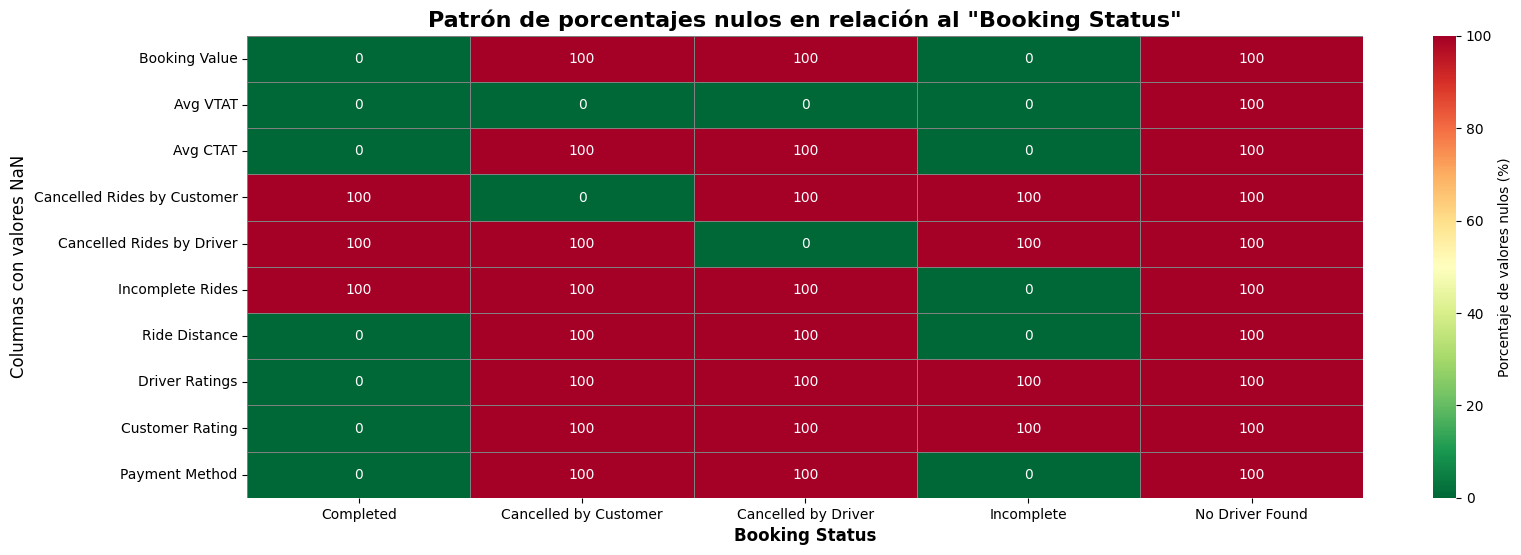

In [31]:
# Crear el heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(df_heatmap, 
            annot=True,  # True: Muestra los valores | False: Esconde los valores
            fmt='.0f',   # Sin decimales
            cmap='RdYlGn_r',  # Rojo = muchos nulos, Verde = pocos nulos
            cbar_kws={'label': 'Porcentaje de valores nulos (%)'},
            linewidths=0.5,
            linecolor='gray')

plt.title('Patrón de porcentajes nulos en relación al "Booking Status"', fontsize=16, fontweight='bold')
plt.xlabel('Booking Status', fontsize=12, fontweight='bold')
plt.ylabel('Columnas con valores NaN', fontsize=12)
plt.xticks(rotation=0, ha='center')

plt.show()

## Conclusiones sobre los datos
**Sobre los datos nulos (NaN):**

Hay una relación directa entre los datos nulos y el estado de la reserva:
- ```Completed```: Están todos los datos necesarios.
- ```Cancelled by Customer```/```Cancelled by Driver```: tienen información parcial, porque el viaje no se realizó.
- ```Incomplete```: tiene algo de data, pero no es el viaje entero
- ```No driver Found```: no tiene data del viaje

**Conclusiones**
- Los datos que faltan (NaN) obedecen a un tema de diseño, no a un problema de carga de datos.
- Los datos que faltan (NaN) son información en sí mismos.

In [32]:
#df['Booking Status'].unique().tolist()
#cols = df.columns
key_columns = ['Booking Status', 'Vehicle Type', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 
'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Driver Ratings', 'Customer Rating', 'Payment Method']

for col in df[key_columns]:
    u = df[col].unique().tolist()
    print (f"Valores únicos de {col}: {u}")



Valores únicos de Booking Status: ['No Driver Found', 'Incomplete', 'Completed', 'Cancelled by Driver', 'Cancelled by Customer']
Valores únicos de Vehicle Type: ['eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike', 'Go Mini', 'Uber XL']
Valores únicos de Cancelled Rides by Customer: [nan, 1.0]
Valores únicos de Reason for cancelling by Customer: [nan, 'Driver is not moving towards pickup location', 'Driver asked to cancel', 'AC is not working', 'Change of plans', 'Wrong Address']
Valores únicos de Cancelled Rides by Driver: [nan, 1.0]
Valores únicos de Driver Cancellation Reason: [nan, 'Personal & Car related issues', 'Customer related issue', 'More than permitted people in there', 'The customer was coughing/sick']
Valores únicos de Incomplete Rides: [nan, 1.0]
Valores únicos de Incomplete Rides Reason: [nan, 'Vehicle Breakdown', 'Other Issue', 'Customer Demand']
Valores únicos de Driver Ratings: [nan, 4.9, 4.6, 4.1, 4.0, 4.4, 4.2, 4.7, 3.8, 5.0, 3.7, 3.1, 4.5, 3.9, 4.3, 3.3, 3.2, 4.8